In [2]:
!unzip -q /content/amhcd-data-64.zip

In [17]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

def load_tifinagh_dataset_from_csv(data_dir, csv_path, img_size=32):

    # Lire CSV
    df = pd.read_csv(csv_path, header=None, names=["image_path", "label"], sep=",")

    # Nettoyer chemins → relatifs au dossier data_dir
    prefix = "./images-data-64/tifinagh-images/"
    df["rel_path"] = df["image_path"].apply(lambda p: p.replace(prefix, "").replace("\\", "/"))

    # Créer le mapping label → index
    unique_labels = sorted(df["label"].unique())
    class_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
    idx_to_class = {idx: label for label, idx in class_to_idx.items()}

    # Créer le mapping chemin relatif → label index
    img_to_label = dict(zip(df["rel_path"], df["label"].map(class_to_idx)))

    X, y = [], []

    for root, _, files in os.walk(data_dir):
        for fname in files:
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif")):
                full_path = os.path.join(root, fname)
                rel_path = os.path.relpath(full_path, start=data_dir).replace("\\", "/")

                if rel_path not in img_to_label:
                    continue  # ignorer les images non listées dans le CSV

                label = img_to_label[rel_path]
                try:
                    img = Image.open(full_path).convert("L").resize((img_size, img_size))
                    X.append(np.array(img) / 255.0)
                    y.append(label)
                except Exception as e:
                    print(f"Erreur image {rel_path} : {e}")

    X = np.expand_dims(np.array(X), axis=1)  # (N, 1, H, W)
    y = np.array(y)
    return X, y, idx_to_class


In [18]:
def visualize_examples(X, y, idx_to_class, n=6):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        idx = random.randint(0, len(X) - 1)
        img = X[idx][0]  # (1, H, W)
        label_char = idx_to_class[y[idx]]

        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {label_char}", fontsize=14)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


Images chargées : 28182
Nombre de classes : 33


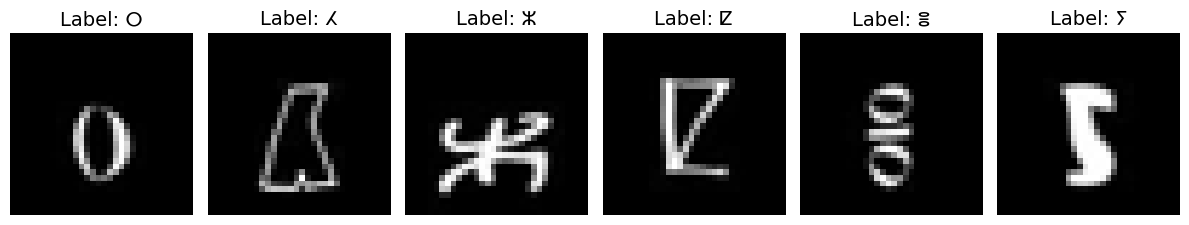

In [19]:
data_dir = "/content/amhcd-data-64/tifinagh-images"
csv_path = "/content/amhcd-data-64/labels-map.csv"

X, y, idx_to_class = load_tifinagh_dataset_from_csv(data_dir, csv_path)
print(f"Images chargées : {len(X)}")
print(f"Nombre de classes : {len(idx_to_class)}")

visualize_examples(X, y, idx_to_class)


In [35]:
def one_hot(y, num_classes):
    return np.eye(num_classes)[y]

<h1> Les couches <h1>

In [36]:
def conv2d(x, w, b, stride=1):
    batch, c, h, w_ = x.shape
    n_filters, _, kh, kw = w.shape
    out_h = (h - kh) // stride + 1
    out_w = (w_ - kw) // stride + 1
    output = np.zeros((batch, n_filters, out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            x_slice = x[:, :, i*stride:i*stride+kh, j*stride:j*stride+kw]
            for f in range(n_filters):
                output[:, f, i, j] = np.sum(x_slice * w[f], axis=(1,2,3)) + b[f]
    return output

def avg_pool2d(x, size=2, stride=2):
    batch, c, h, w = x.shape
    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1
    output = np.zeros((batch, c, out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            x_slice = x[:, :, i*stride:i*stride+size, j*stride:j*stride+size]
            output[:, :, i, j] = np.mean(x_slice, axis=(2,3))
    return output

def flatten(x):
    return x.reshape(x.shape[0], -1)

def dense(x, w, b):
    return np.dot(x, w) + b

def tanh(x):
    return np.tanh(x)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy(pred, labels):
    return -np.mean(np.sum(labels * np.log(pred + 1e-8), axis=1))

def accuracy(pred, labels):
    return np.mean(np.argmax(pred, axis=1) == np.argmax(labels, axis=1))


<h1> La création du modèle LeNet-5</h1>





In [37]:
class LeNet5:
    def __init__(self, num_classes=33):
        self.num_classes = num_classes
        self.init_weights()

    def init_weights(self):
        self.params = {
            'wc1': np.random.randn(6, 1, 5, 5) * 0.1,
            'bc1': np.zeros(6),
            'wc3': np.random.randn(16, 6, 5, 5) * 0.1,
            'bc3': np.zeros(16),
            'wf5': np.random.randn(16*5*5, 120) * 0.1,
            'bf5': np.zeros(120),
            'wf6': np.random.randn(120, 84) * 0.1,
            'bf6': np.zeros(84),
            'wout': np.random.randn(84, self.num_classes) * 0.1,
            'bout': np.zeros(self.num_classes)
        }

    def forward(self, x):
        self.x = x
        self.c1 = tanh(conv2d(x, self.params['wc1'], self.params['bc1']))
        self.s2 = avg_pool2d(self.c1)
        self.c3 = tanh(conv2d(self.s2, self.params['wc3'], self.params['bc3']))
        self.s4 = avg_pool2d(self.c3)
        self.flat = flatten(self.s4)
        self.f5 = tanh(dense(self.flat, self.params['wf5'], self.params['bf5']))
        self.f6 = tanh(dense(self.f5, self.params['wf6'], self.params['bf6']))
        self.out = softmax(dense(self.f6, self.params['wout'], self.params['bout']))
        return self.out

    def predict(self, x):
        out = self.forward(x)
        return np.argmax(out, axis=1)


<h1> Opimizers SGD & ADAM </h1>

In [38]:
def sgd(params, grads, lr=0.01):
    for key in params.keys():
        params[key] -= lr * grads[key]

class AdamOptimizer:
    def __init__(self, parameters, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.params = parameters
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0
        self.m = {k: np.zeros_like(v) for k, v in parameters.items()}
        self.v = {k: np.zeros_like(v) for k, v in parameters.items()}

    def step(self, grads):
        self.t += 1
        for k in self.params.keys():
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (grads[k] ** 2)
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            self.params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)



<h1> Entrainement de modele<h1>

In [39]:
def train(model, X_train, y_train, X_val, y_val, optimizer_type="sgd", epochs=10, batch_size=32, lr=0.01):
    losses, accs = [], []
    y_train_oh = one_hot(y_train, model.num_classes)
    y_val_oh = one_hot(y_val, model.num_classes)

    if optimizer_type == "adam":
        optimizer = AdamOptimizer(model.params, lr=lr)
    else:
        optimizer = None  # For SGD

    for epoch in range(epochs):
        total_loss = 0
        total_acc = 0
        for i in range(0, len(X_train), batch_size):
            x_batch = X_train[i:i+batch_size]
            y_batch = y_train_oh[i:i+batch_size]

            out = model.forward(x_batch)
            loss = cross_entropy(out, y_batch)
            acc = accuracy(out, y_batch)

            total_loss += loss * len(x_batch)
            total_acc += acc * len(x_batch)


            grads = {k: np.zeros_like(v) for k, v in model.params.items()}

            if optimizer_type == "adam":
                optimizer.step(grads)
            else:
                sgd(model.params, grads, lr)

        val_out = model.forward(X_val)
        val_loss = cross_entropy(val_out, y_val_oh)
        val_acc = accuracy(val_out, y_val_oh)

        print(f"[{epoch+1}] Loss={total_loss/len(X_train):.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        losses.append((total_loss / len(X_train), val_loss))
        accs.append((total_acc / len(X_train), val_acc))

    return losses, accs


<h1> Visualisation </h1>

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_metrics(losses, accs):
    train_loss, val_loss = zip(*losses)
    train_acc, val_acc = zip(*accs)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.legend()
    plt.title("Loss over epochs")

    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.legend()
    plt.title("Accuracy over epochs")

    plt.show()

def show_confusion_matrix(y_true, y_pred, class_labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


In [43]:
from sklearn.model_selection import train_test_split


dataset_path = "path/to/tifinagh_dataset"  #
img_size = 32
epochs = 10
batch_size = 16
learning_rate = 0.001
optimizer_choice = "adam"

# Chargement des données =
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Taille du dataset d'entraînement :", X_train.shape)
print("Taille du dataset de validation :", X_val.shape)
# Initialisation du modèle
num_classes = len(idx_to_class)

model = LeNet5(num_classes=num_classes)

# # Entraînement
losses, accs = train(model, X_train, y_train, X_val, y_val,
                     optimizer_type=optimizer_choice,
                     epochs=epochs, batch_size=batch_size, lr=learning_rate)


In [ ]:
# Visualisation traning and validation losses
plot_metrics(losses, accs)

In [ ]:
# # Prédiction et matrice de confusion
y_pred = model.predict(X_val)
show_confusion_matrix(y_val, y_pred, class_labels=[str(i) for i in range(num_classes)])